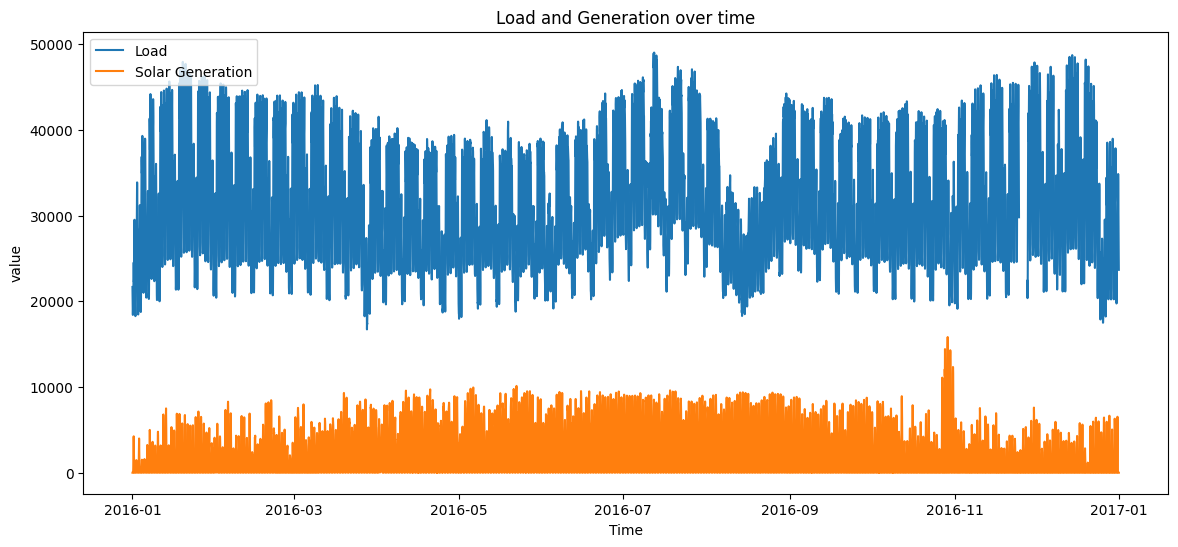

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

df = pd.read_csv('/content/sample_data/TimeSeries_TotalSolarGen_and_Load_IT_2016.csv')

df.head()
df['utc_timestamp'] = pd.to_datetime(df['utc_timestamp'])

plt.figure(figsize=(14,6))
plt.plot(df['utc_timestamp'],df['IT_load_new'],label='Load')
plt.plot(df['utc_timestamp'],df['IT_solar_generation'],label='Solar Generation')
plt.xlabel('Time')
plt.ylabel('value')
plt.legend()
plt.title('Load and Generation over time')
plt.show()

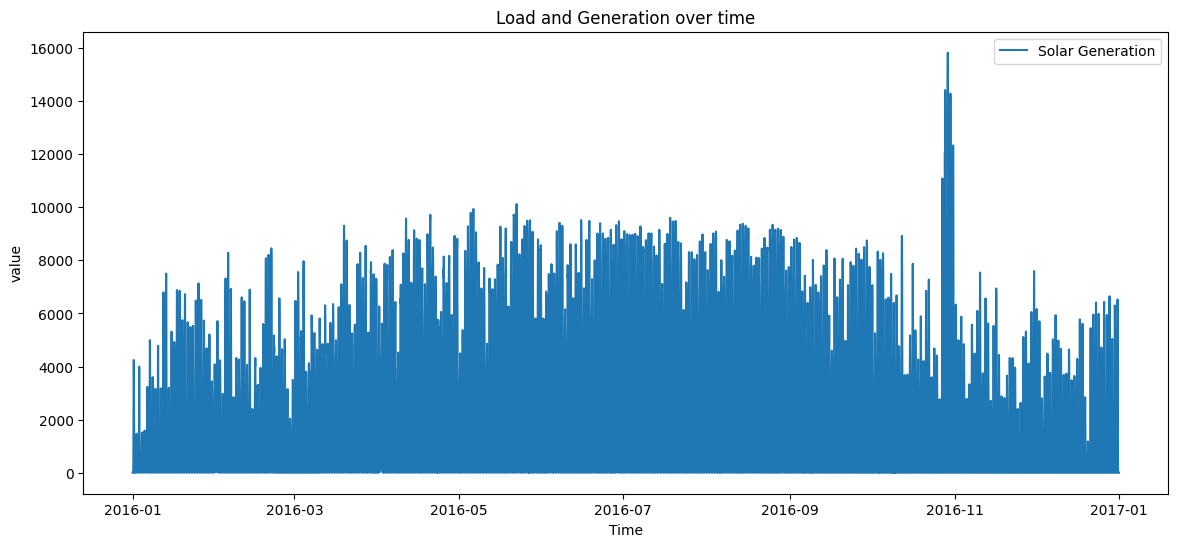

In [24]:

plt.figure(figsize=(14,6))
plt.plot(df['utc_timestamp'],df['IT_solar_generation'],label='Solar Generation')
plt.xlabel('Time')
plt.ylabel('value')
plt.legend()
plt.title('Load and Generation over time')
plt.show()

In [25]:
# handling missing values
df.isnull().sum()

# fill missing values using forward fill
df['IT_load_new'] = df['IT_load_new'].ffill()

#check for missing values again
# print(df.isnull().sum())

def test_stationarity(timeseries):

  # perform Dickey - Fuller Test  #### AIC = Akaike Information Criterion -- Lower AIC = Better model
  print("Results of Dickey-Fuller Test : ")
  dftest = adfuller(timeseries,autolag='AIC')  # ADF test automatically best lag choose karta hai - Lag = kitne previous time steps consider karne hain
  dfoutput = pd.Series(dftest[0:4],index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
  for key,value in dftest[4].items():
    dfoutput['Critical Value(%s)'%key] = value
  print(dfoutput)

# perform ADF test (Augumented Dickey-Fuller test)

print("\nADF test for 'IT_load_new' after filling missing values")
test_stationarity(df['IT_load_new'])

print("\nADF test for 'IT_solar_generation' ")
test_stationarity(df['IT_solar_generation'])


ADF test for 'IT_load_new' after filling missing values
Results of Dickey-Fuller Test : 
Test Statistic                -1.197390e+01
p-value                        3.841445e-22
#Lags Used                     3.700000e+01
Number of Observations Used    8.746000e+03
Critical Value(1%)            -3.431098e+00
Critical Value(5%)            -2.861871e+00
Critical Value(10%)           -2.566946e+00
dtype: float64

ADF test for 'IT_solar_generation' 
Results of Dickey-Fuller Test : 
Test Statistic                -5.741335e+00
p-value                        6.265438e-07
#Lags Used                     3.600000e+01
Number of Observations Used    8.747000e+03
Critical Value(1%)            -3.431098e+00
Critical Value(5%)            -2.861870e+00
Critical Value(10%)           -2.566946e+00
dtype: float64


In [26]:
# ffill (Forward Fill) Fill missing value using previous (above) value

# Before : 10,NaN,NaN,20
# After ffill: 10,10,10,20

# bfill (Backward Fill) Fill missing value using next (below) value

# Before: 10,NaN,NaN,20
# After bfill:10,20,20,20

In [29]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt

train_size = int(len(df['IT_load_new'])*0.8)
train,test = df['IT_load_new'][:train_size] , df['IT_load_new'][train_size:]

model = ARIMA(train,order=(2,0,2))
model_fit = model.fit()

# make prediction on the test size
predictions = model_fit.predict(start=len(train),end=len(train)+len(test)-1)
rmse = sqrt(mean_squared_error(test,predictions))
print("rmse : " , rmse)

rmse :  7714.95213482925


In [32]:

model2 = ARIMA(train,order=(2,1,2))
model_fit2 = model2.fit()

# make prediction on the test size
predictions2 = model_fit2.predict(start=len(train),end=len(train)+len(test)-1)
rmse2 = sqrt(mean_squared_error(test,predictions2))
print("rmse : " , rmse2)

rmse :  7993.84942771682


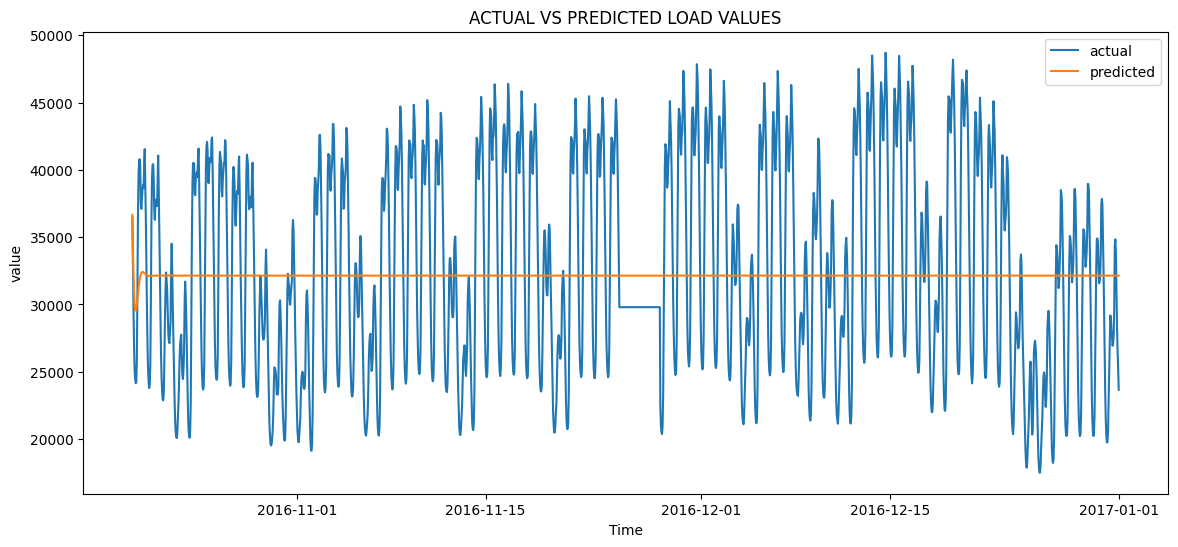

In [34]:

plt.figure(figsize=(14,6))
plt.plot(df['utc_timestamp'][train_size:],test,label='actual')
plt.plot(df['utc_timestamp'][train_size:],predictions,label='predicted')
plt.xlabel('Time')
plt.ylabel('value')
plt.legend()
plt.title('ACTUAL VS PREDICTED LOAD VALUES')
plt.show()